# **Aprendizaje Automático 1**
## EDA - Modelo estimación valor inmuebles (predicción de MEDV)

**Integrantes:** Alejandro Acosta, Diego Hauret, Gastón Rinaldi, Agustín Torres

Análisis exploratorio de datos previo a la construcción de un modelo de regresión para predecir **MEDV** (valor medio de las viviendas, en miles de USD).

**Indice:**
1. Carga y comprensión de los datos
2. Análisis de valores faltantes
3. Imputación de valores faltantes (ejemplo)
4. Análisis univariado (variable objetivo y predictoras)
5. Análisis bivariado (correlaciones y relación con MEDV)
6. Multicolinealidad entre predictoras
7. Detección de outliers
8. Conclusiones y próximos pasos


## 0. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga y comprensión de los datos

Diccionario de variables:

| Variable | Descripción |
|---|---|
| CRIM | Tasa de criminalidad per cápita por localidad |
| ZN | % de suelo residencial en lotes grandes |
| INDUS | % de acres de negocio no minorista por localidad |
| CHAS | Variable dummy (1 si limita con el río Charles, 0 si no) |
| NOX | Concentración de óxidos de nitrógeno |
| RM | Promedio de habitaciones por vivienda |
| AGE | % de viviendas ocupadas por el propietario construidas antes de 1940 |
| DIS | Distancia ponderada a 5 centros de empleo de Boston |
| RAD | Índice de accesibilidad a autopistas radiales |
| TAX | Tasa de impuesto a la propiedad por cada $10.000 |
| PTRATIO | Ratio alumno-profesor por localidad |
| B | 1000(Bk - 0.63)^2, donde Bk es la proporción de población afroamericana |
| LSTAT | % de población de estatus socioeconómico bajo |
| MEDV | **Variable objetivo**: valor medio de la vivienda (en miles de USD) |


In [2]:
df = pd.read_csv('../data/house-prices-tp.csv')
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (556, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [4]:
df.describe().T
desc = df.describe().T
desc['mediana'] = df.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df.skew()
desc['curtosis'] = df.kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]


Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.8455,0.3153,13.8286,236.5681,0.0063,0.0845,0.3153,4.8714,88.9762,3.7467,15.2487
ZN,13.1972,0.0000,24.9030,188.6993,0.0000,0.0000,0.0000,20.0000,100.0000,1.9578,2.7498
INDUS,11.2187,9.6900,6.9420,61.8789,0.4600,5.1300,9.6900,18.1000,27.7400,0.3015,-1.2064
CHAS,0.0901,0.0000,0.2865,318.1691,0.0000,0.0000,0.0000,0.0000,1.0000,2.8722,6.2731
NOX,0.5600,0.5380,0.1195,21.3325,0.3850,0.4530,0.5380,0.6440,0.8710,0.6944,-0.2296
RM,6.2918,6.2080,0.7824,12.4352,3.5610,5.8755,6.2080,6.6385,8.7800,0.3738,1.5551
AGE,67.6323,76.5000,28.4619,42.0833,2.9000,42.2750,76.5000,93.8250,100.0000,-0.5507,-1.0382
DIS,3.9441,3.3401,2.2557,57.1914,1.1296,2.1121,3.3401,5.4007,12.1265,1.0789,0.7054
RAD,9.6994,5.0000,8.6845,89.5366,1.0000,4.0000,5.0000,23.6327,24.0000,0.9515,-0.9478
TAX,409.5751,335.0000,167.6894,40.9423,187.0000,279.0000,335.0000,666.0000,711.0000,0.6323,-1.1705


In [5]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


## 2. Análisis de valores faltantes


Revisamos cuántos nulos tiene cada columna y si hay algún patrón (filas con muchos nulos a la vez, o nulos concentrados).


In [6]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
PTRATIO,28,5.0400
RAD,28,5.0400
NOX,24,4.3200
AGE,24,4.3200
CHAS,23,4.1400
CRIM,23,4.1400
LSTAT,22,3.9600
B,22,3.9600
ZN,22,3.9600
RM,21,3.7800


Se observa que la variable objetivo (MEDV) tiene 21 valores faltantes. Estos registros se eliminan porque son valores NaN de la variable a predecir.

In [7]:
df = df.dropna(subset=["MEDV"])
print("Filas con nulos en MEDV:", df["MEDV"].isna().sum())

Filas con nulos en MEDV: 0


In [8]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
RAD,12,2.2400
CRIM,11,2.0600
AGE,11,2.0600
ZN,11,2.0600
CHAS,9,1.6800
NOX,9,1.6800
LSTAT,9,1.6800
B,9,1.6800
TAX,9,1.6800
PTRATIO,9,1.6800


In [9]:
# Análisis de la variable CHAS por desbalanceo
df['CHAS'].value_counts(normalize=True)


CHAS
0.0000   0.9144
1.0000   0.0856
Name: proportion, dtype: float64

Debido al desbalanceo observado descartamos la variable CHAS

In [10]:
df = df.drop(columns=['CHAS'])

In [11]:
nulos_por_fila = df.isna().sum(axis=1)
print("Cantidad de nulos por fila:\n",nulos_por_fila.value_counts().sort_index())


Cantidad de nulos por fila:
 0    506
1      5
2      4
3      9
4      1
5      3
6      4
7      1
8      2
Name: count, dtype: int64


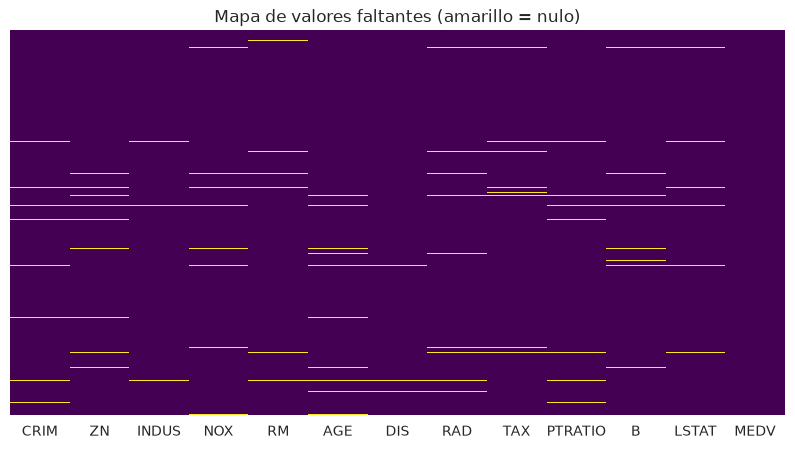

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
#cbar=False desactiva la barra lateral de medidas
#yticklabels=False oculta las etiquetas de valores del eje y
ax.set_title("Mapa de valores faltantes (amarillo = nulo)")
plt.show()


## 3. Imputación de valores faltantes



In [23]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df_imputado_median = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("Nulos luego de imputar:", df_imputado_median.isna().sum().sum())
df_imputado_median.describe()


Nulos luego de imputar: 0


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000,535.0000
mean,4.8903,12.2456,11.2147,0.5581,6.2755,67.8376,3.8896,9.5205,407.9258,18.4324,351.5435,12.9416,22.7468
std,11.8376,24.0998,6.9002,0.1176,0.7488,28.2982,2.1960,8.5956,166.7361,2.1778,96.1418,7.4508,9.4915
min,0.0063,0.0000,0.4600,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0856,0.0000,5.1600,0.4530,5.8775,42.7000,2.1103,4.0000,280.3409,17.1500,372.2850,7.1850,16.7500
50%,0.2903,0.0000,9.6900,0.5380,6.1985,76.5000,3.3175,5.0000,334.0000,19.0000,390.9450,11.4650,21.2000
75%,4.3050,19.0000,18.1000,0.6310,6.6295,93.7000,5.2660,21.1588,666.0000,20.2000,395.8500,17.1150,26.3000
max,88.9762,100.0000,27.7400,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


In [24]:
faltante = df_imputado_median.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df_imputado_median) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
CRIM,0,0.0000
ZN,0,0.0000
INDUS,0,0.0000
NOX,0,0.0000
RM,0,0.0000
AGE,0,0.0000
DIS,0,0.0000
RAD,0,0.0000
TAX,0,0.0000
PTRATIO,0,0.0000


## 4. Análisis univariado



### 4.1 Variable objetivo: MEDV

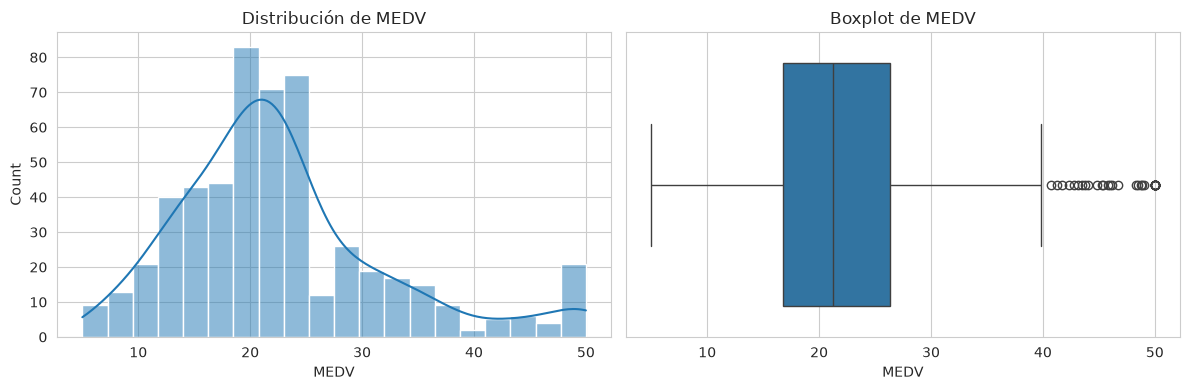

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_imputado_median["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df_imputado_median["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.show()


### 4.2 Distribución de las predictoras

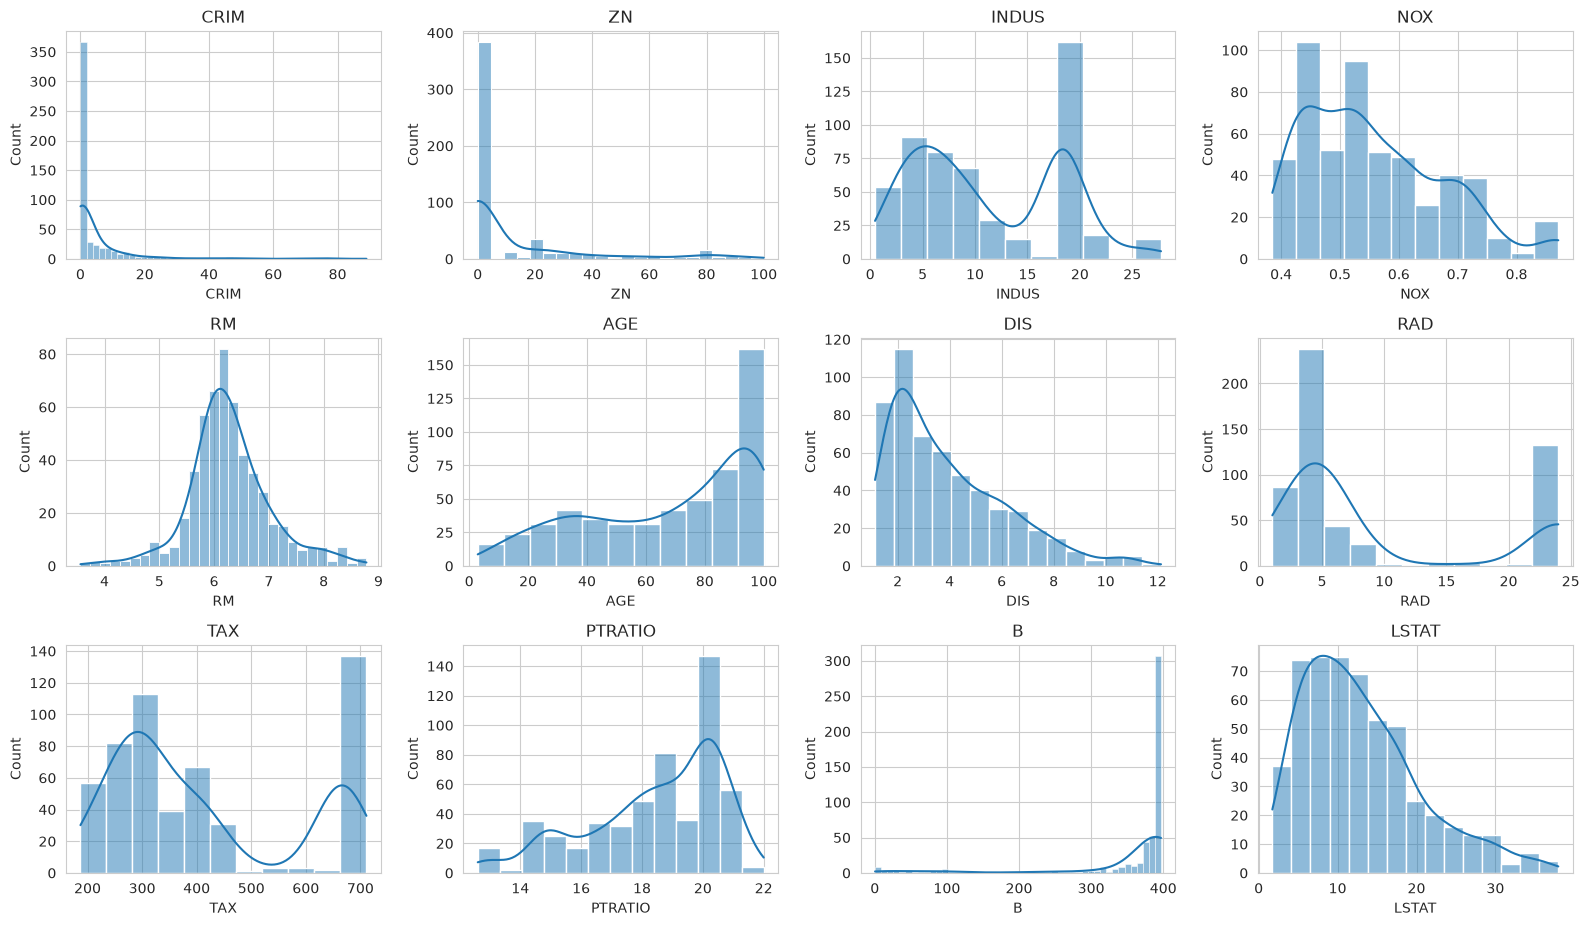

In [26]:
cols = [c for c in df_imputado_median.columns if c != "MEDV"]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(df_imputado_median[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [29]:
columnas1 = ['B','TAX']
columnas2 = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','RAD','PTRATIO','LSTAT']

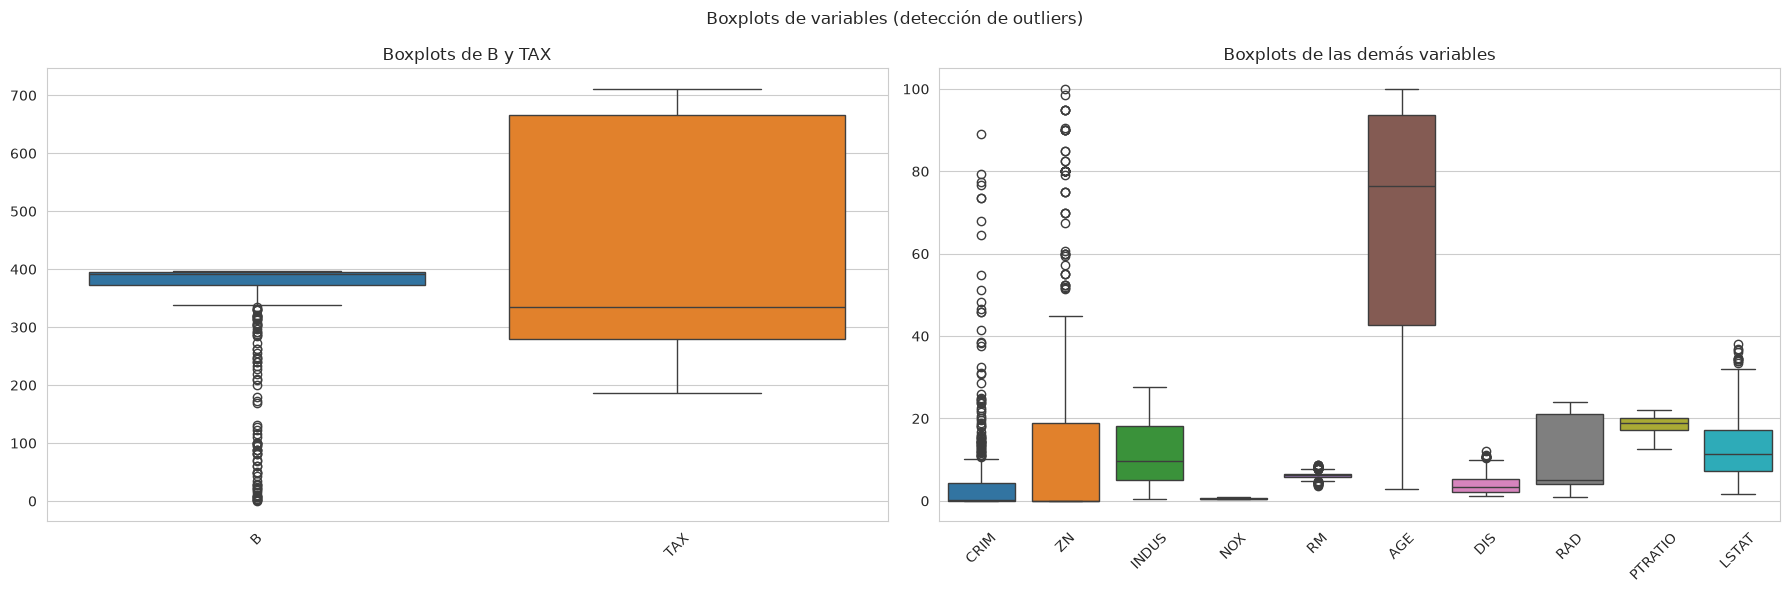

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_imputado_median[columnas1], ax=axes[0])
axes[0].set_title("Boxplots de B y TAX")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_imputado_median[columnas2], ax=axes[1])
axes[1].set_title("Boxplots de las demás variables")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Boxplots de variables (detección de outliers)")
plt.tight_layout()
plt.show()

## 5. Análisis bivariado



### 5.1 Matriz de correlación

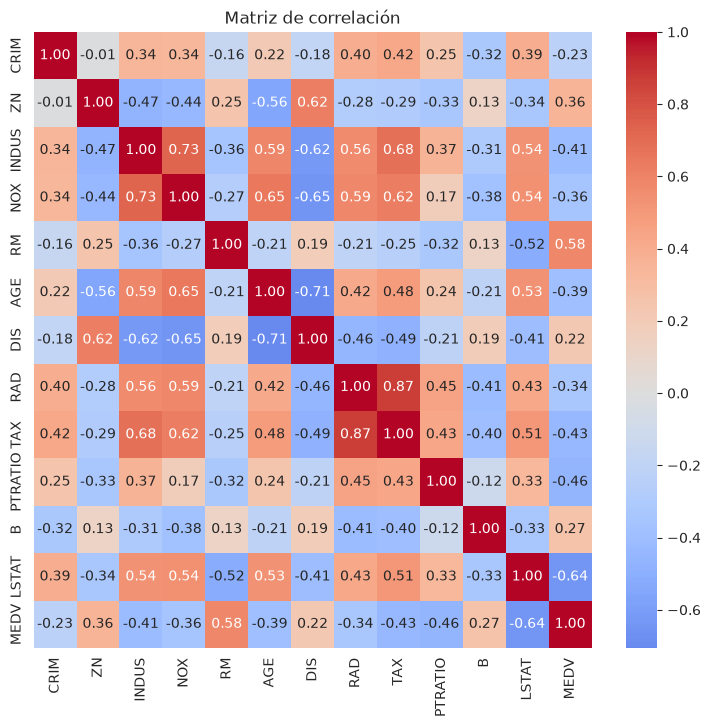

In [33]:
corr = df_imputado_median.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()


In [34]:
corr_medv = corr["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)
print("Correlación de cada variable con MEDV (ordenada por magnitud):")
print(corr_medv.round(3))


Correlación de cada variable con MEDV (ordenada por magnitud):
LSTAT     -0.6430
RM         0.5800
PTRATIO   -0.4590
TAX       -0.4330
INDUS     -0.4150
AGE       -0.3940
NOX       -0.3570
ZN         0.3560
RAD       -0.3360
B          0.2650
CRIM      -0.2270
DIS        0.2210
Name: MEDV, dtype: float64


### 5.2 Relación de las variables más correlacionadas con MEDV

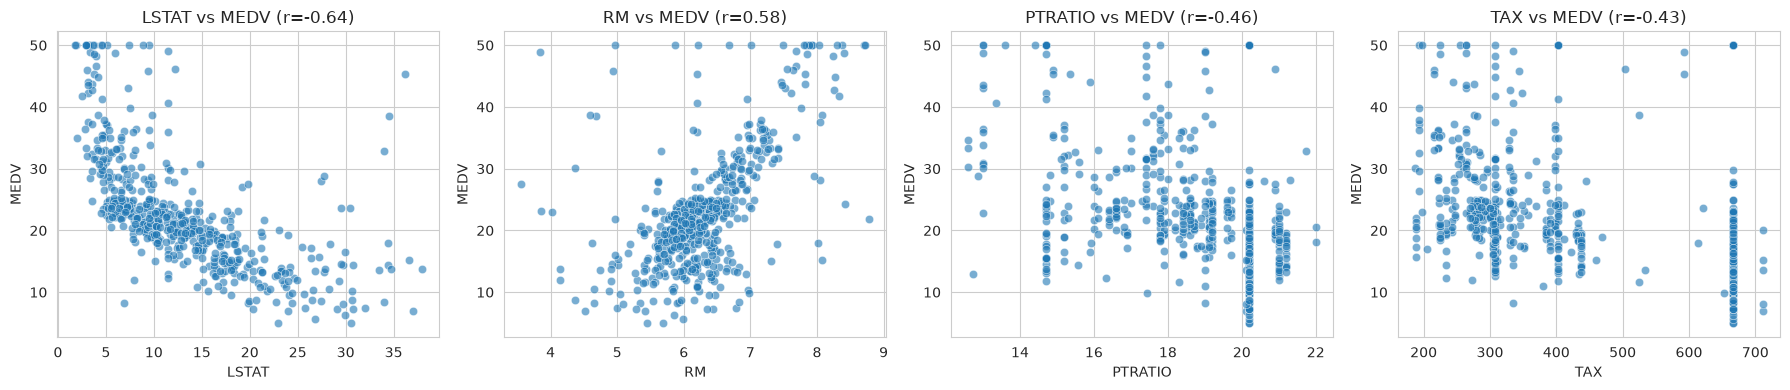

In [36]:
top_vars = corr_medv.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, len(top_vars), figsize=(18, 4))
for ax, col in zip(axes, top_vars):
    sns.scatterplot(x=df_imputado_median[col], y=df_imputado_median["MEDV"], ax=ax, alpha=0.6)
    ax.set_title(f"{col} vs MEDV (r={corr_medv[col]:.2f})")
plt.tight_layout()
plt.show()


## 6. Multicolinealidad entre predictoras


Calculamos el VIF (Variance Inflation Factor) de cada predictora usando regresiones lineales (sin depender de `statsmodels`). Un VIF alto (>5-10) sugiere redundancia entre variables.


In [39]:
def compute_vif(data, features):
    vif_values = {}
    data = data[features].dropna()
    for f in features:
        X = data.drop(columns=[f]).values
        y = data[f].values
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif_values[f] = np.inf if r2 == 1 else 1 / (1 - r2)
    return pd.Series(vif_values).sort_values(ascending=False)

vif = compute_vif(df_imputado_median, cols)
print(vif.round(2))


TAX       5.6100
RAD       4.7700
NOX       3.2700
INDUS     3.1600
DIS       2.7900
AGE       2.6400
LSTAT     2.2300
ZN        1.9600
PTRATIO   1.6200
RM        1.5000
CRIM      1.4000
B         1.3300
dtype: float64


Descartamos TAX porque tiene un valor de VIF mayor a 5 (correlación severa).

In [41]:
df_imputado_median.drop(columns=['TAX'], inplace=True)

In [42]:
df_imputado_median.info()

<class 'pandas.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     535 non-null    float64
 1   ZN       535 non-null    float64
 2   INDUS    535 non-null    float64
 3   NOX      535 non-null    float64
 4   RM       535 non-null    float64
 5   AGE      535 non-null    float64
 6   DIS      535 non-null    float64
 7   RAD      535 non-null    float64
 8   PTRATIO  535 non-null    float64
 9   B        535 non-null    float64
 10  LSTAT    535 non-null    float64
 11  MEDV     535 non-null    float64
dtypes: float64(12)
memory usage: 50.3 KB


## 7. Detección de outliers

Boxplots de todas las variables (estandarizadas para poder compararlas en la misma escala).


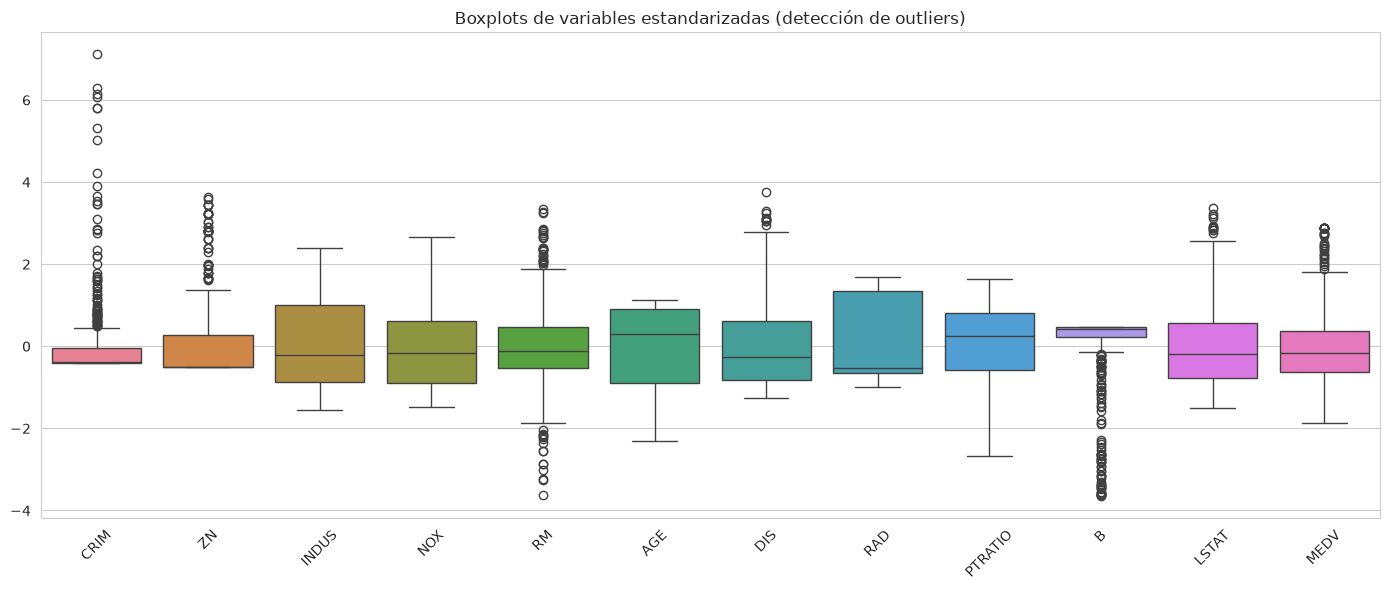

In [43]:
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_imputado_median.dropna()),
    columns=df_imputado_median.columns
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_scaled, ax=ax)
plt.xticks(rotation=45)
ax.set_title("Boxplots de variables estandarizadas (detección de outliers)")
plt.tight_layout()
plt.show()


In [46]:
def outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outliers = {c: outlier_summary(df_scaled[c].dropna()) for c in df_scaled.columns}
pd.Series(outliers).sort_values(ascending=False)


B          87
CRIM       69
ZN         55
RM         42
MEDV       37
LSTAT      11
DIS        10
INDUS       0
NOX         0
AGE         0
RAD         0
PTRATIO     0
dtype: int64

In [47]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,535.0000,-0.0000,1.0009,-0.4130,-0.4063,-0.3890,-0.0495,7.1099
ZN,535.0000,0.0000,1.0009,-0.5086,-0.5086,-0.5086,0.2805,3.6447
INDUS,535.0000,0.0000,1.0009,-1.5601,-0.8783,-0.2212,0.9988,2.3971
NOX,535.0000,0.0000,1.0009,-1.4739,-0.8950,-0.1715,0.6201,2.6630
RM,535.0000,-0.0000,1.0009,-3.6286,-0.5320,-0.1029,0.4733,3.3479
AGE,535.0000,-0.0000,1.0009,-2.2969,-0.8891,0.3064,0.9148,1.1376
DIS,535.0000,0.0000,1.0009,-1.2580,-0.8110,-0.2608,0.6274,3.7543
RAD,535.0000,-0.0000,1.0009,-0.9922,-0.6428,-0.5264,1.3553,1.6861
PTRATIO,535.0000,0.0000,1.0009,-2.6806,-0.5894,0.2609,0.8124,1.6397
B,535.0000,-0.0000,1.0009,-3.6566,0.2159,0.4102,0.4613,0.4722


## 8. Conclusiones y próximos pasos

Completar esta sección con los hallazgos concretos una vez revisados los resultados de arriba, por ejemplo:

- **Variables más predictivas**: según la correlación con MEDV (revisar sección 5.1), probablemente RM y LSTAT.
- **Multicolinealidad**: variables con VIF alto (sección 6) — eliminamos la variable TAX porque tenía un valor mayor a 5.
- **Estrategia de imputación**: definimos imputacion por mediana debido a la cantidad de outliers que podrían afectar el estudio  si usamos imputación por KNN.
- **Outliers**: podemos observar que los outliers no superan el 20% para cada variable. 
- **Siguiente paso**: separar train/test, aplicar las transformaciones definidas y probar un primer modelo (regresión lineal) antes de pasar a modelos más complejos.


## 9. Validación cruzada TRAIN-TEST


In [58]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_scaled.drop(columns="MEDV")
y = df_scaled["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LinearRegression()

# Validacion cruzada sobre el conjunto de entrenamiento
scores_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring="r2")
print("R2 de cada fold:", scores_cv.round(3))
print("R2 promedio CV:", scores_cv.mean().round(3))

# Entrenamiento y evaluacion final sobre el conjunto de prueba
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("\nResultados en test:")
print("R2:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))

R2 de cada fold: [0.595 0.323 0.792 0.529 0.635]
R2 promedio CV: 0.575

Resultados en test:
R2: 0.332
MAE: 0.452
RMSE: 0.732


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    La función ajusta los pesos W de un modelo lineal de la forma:
        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Parámetros
    ----------
    X_train :
      np.ndarray Matriz de características de entrenamiento de dimensiones (n, m), donde n es la cantidad de muestras y m la cantidad de variables.
    y_train :
      np.ndarray Vector de valores objetivo de entrenamiento de dimensiones (n, 1).
    X_val :
      np.ndarray Matriz de características de validación de dimensiones (p, m), donde p es la cantidad de muestras de validación.
    y_val :
      np.ndarray Vector de valores objetivo de validación de dimensiones (p, 1).
    lr :
      float, optional Tasa de aprendizaje utilizada para actualizar los pesos. Por defecto es 0.01.
    epochs :
      int, optional Cantidad de iteraciones del algoritmo de Gradient Descent. Por defecto es 100.

    Retorna
    -------
    np.ndarray Vector de pesos W de dimensiones (m + 1, 1), incluyendo el término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_val para representar el término independiente (bias).
    2. Se inicializan aleatoriamente los pesos W.
    3. En cada época:
      - Se calcula la predicción sobre el conjunto de entrenamiento.
      - Se calcula el MSE de entrenamiento.
      - Se calcula la predicción sobre el conjunto de validación.
      - Se calcula el MSE de validación.
      - Se calcula el gradiente de la función de costo respecto de W.
      - Se actualizan los pesos utilizando la regla de Gradient Descent: W = W - lr * gradient
      4. Finalmente, se grafica la evolución del MSE de entrenamiento y validación a lo largo de las épocas.
        El gradiente utilizado corresponde a: ∇J(W) = -(2 / n) X.T (y - XW) donde J(W) es el Error Cuadrático Medio.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [55]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Stochastic Gradient Descent (SGD).

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    A diferencia de Gradient Descent tradicional, que calcula el gradiente
    utilizando todas las muestras antes de actualizar los pesos, SGD actualiza
    los pesos después de procesar cada muestra individual.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todas las muestras de entrenamiento. Por defecto es 100.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se permutan aleatoriamente las muestras de entrenamiento
      para evitar que el orden de los datos afecte al proceso de aprendizaje.

    4. Para cada muestra de entrenamiento:
      - Se calcula la predicción.
      - Se calcula el error entre el valor real y la predicción.
      - Se calcula el error cuadrático de esa muestra.
      - Se calcula el gradiente respecto de los pesos.
      - Se actualizan inmediatamente los pesos.

    5. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para observar la evolución del modelo.

    El gradiente utilizado para una muestra individual es:

        ∇J(W) = -2 * x_i.T * (y_i - x_i @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de Gradient Descent tradicional es que
    el gradiente se calcula y los pesos se actualizan utilizando una sola
    muestra por vez, en lugar de utilizar todo el conjunto de entrenamiento.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [56]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    """
    Entrena un modelo de regresión lineal mediante Mini-Batch Gradient Descent.

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Mini-Batch Gradient Descent combina las características de Gradient Descent
    tradicional y Stochastic Gradient Descent (SGD): en lugar de calcular el
    gradiente utilizando todo el conjunto de entrenamiento o una única muestra,
    calcula el gradiente utilizando pequeños lotes (mini-batches) de datos.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todos los mini-batches del conjunto de entrenamiento.
        Por defecto es 100.

    batch_size : int, optional
        Cantidad de muestras utilizadas para calcular cada actualización
        de los pesos. Por defecto es 11.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se realiza una permutación aleatoria de las muestras
      de entrenamiento para evitar que el orden de los datos influya
      sistemáticamente en el aprendizaje.

    4. El conjunto de entrenamiento se divide en mini-batches de tamaño
      batch_size.

    5. Para cada mini-batch:
      - Se calcula la predicción:

            y_pred = X_batch @ W

      - Se calcula el error:

            error = y_batch - y_pred

      - Se calcula el MSE del mini-batch.
      - Se calcula el gradiente utilizando todas las muestras del
        mini-batch.
      - Se actualizan inmediatamente los pesos.

    6. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para evaluar la evolución del modelo.

    El gradiente utilizado es:

        ∇J(W) = -(2 / batch_size) * X_batch.T @ (y_batch - X_batch @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de los otros métodos es el tamaño
    del conjunto utilizado para cada actualización:

        Gradient Descent:
            utiliza todas las muestras.

        Stochastic Gradient Descent:
            utiliza una única muestra.

        Mini-Batch Gradient Descent:
            utiliza un pequeño grupo de muestras.

    Por lo tanto, Mini-Batch Gradient Descent busca un equilibrio entre
    la estabilidad del gradiente calculado sobre todo el dataset y la
    velocidad y frecuencia de actualización característica de SGD.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

In [106]:
X_train.shape, X_val.shape, X_test.shape

((374, 11), (54, 11), (107, 11))

In [96]:
X_train.head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT
124,-0.3890,-0.5086,0.3480,0.8282,0.8809,-1.4731,3.0540,-0.3110,-2.6247,-2.8074,-0.1984
134,-0.3941,-0.5086,-0.0906,-0.5886,0.0675,-0.5425,0.2121,-0.6428,0.0770,0.4511,-0.2649
226,-0.4097,-0.5086,0.3881,-0.0694,-0.5179,-0.4187,-0.3544,-0.5264,-0.9341,0.4295,0.0764
24,-0.4076,-0.5086,-1.0393,-0.4099,-0.3415,-0.7300,-0.1526,-0.5264,-0.8422,0.4340,-0.3804
527,-0.3649,-0.5086,-0.7274,-0.4354,2.7557,0.1932,-0.0233,-0.1771,-0.4745,0.3578,-1.4068


In [107]:
y_train.shape,y_val.shape, y_test.shape

((374,), (54,), (107,))

In [98]:
y_train.head()

124   -1.0344
134    0.1743
226    0.0583
24     0.0478
527    1.9987
Name: MEDV, dtype: float64

In [118]:
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)    
X_val.reset_index(drop=True, inplace=True)
y_val.reset_index(drop=True, inplace=True)


In [119]:
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values
y_train = y_train.values.reshape(-1, 1)
y_val = y_val.values.reshape(-1, 1) 
y_test = y_test.values.reshape(-1, 1) 

In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)


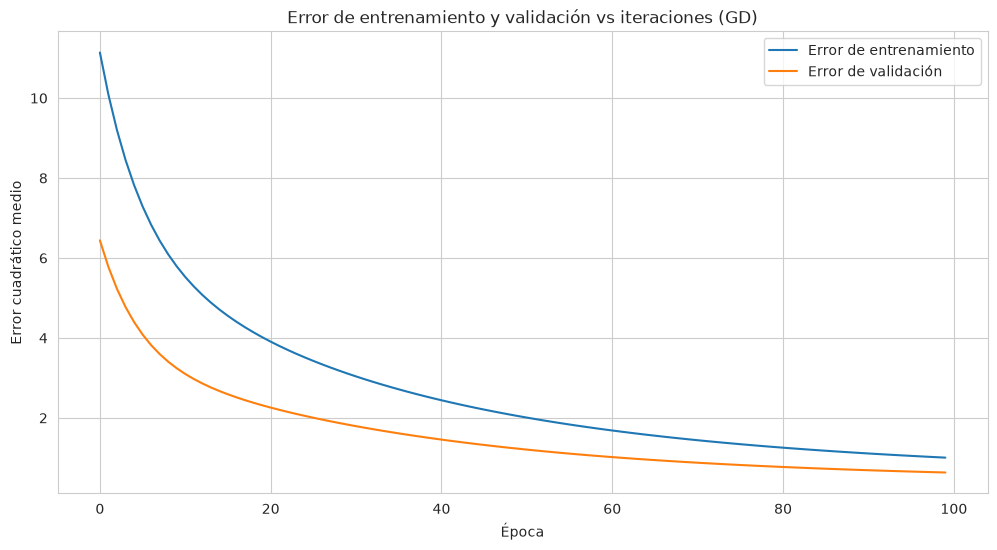

array([[ 0.09229335],
       [-0.00522987],
       [-0.30784661],
       [-0.17294507],
       [ 0.59040158],
       [ 0.5971827 ],
       [-0.53470086],
       [ 0.25802793],
       [-0.44235382],
       [-0.19756473],
       [-0.04886825],
       [ 0.19748363]])

In [145]:
gradient_descent(X_train_scaled, y_train, X_test_scaled, y_test)

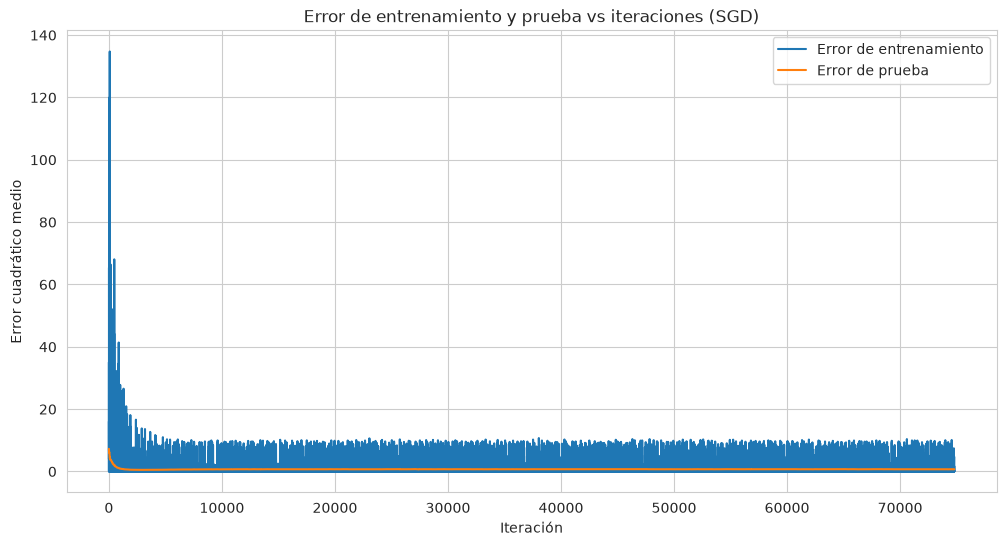

array([[-0.01501865],
       [ 0.0290052 ],
       [ 0.12626828],
       [ 0.03280335],
       [-0.24729363],
       [ 0.26859678],
       [-0.16739651],
       [-0.43622055],
       [ 0.0185542 ],
       [-0.22892994],
       [ 0.06831197],
       [-0.33263252]])

In [141]:
stochastic_gradient_descent(X_train_scaled, y_train, X_test_scaled, y_test, lr=0.001, epochs=200)

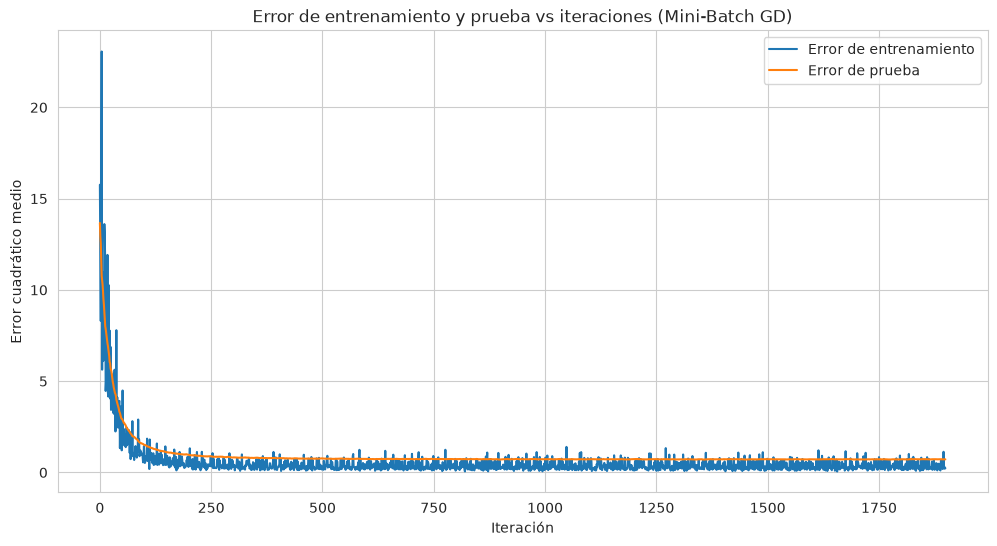

array([[-0.01510299],
       [ 0.0213506 ],
       [ 0.13492577],
       [ 0.01853599],
       [-0.25755482],
       [ 0.28093341],
       [-0.17425872],
       [-0.42587594],
       [ 0.00770557],
       [-0.2386048 ],
       [ 0.081211  ],
       [-0.3396297 ]])

In [142]:
mini_batch_gradient_descent(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, batch_size=20)

In [147]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

